# Project Sixth Sense — Cycle I Feature Pipeline + Cycle II Target Setup

This notebook runs the BIRE preprocessing pipeline, validates the engineered feature set, and prepares the dataset for modeling.

## IMPORTANT TODO: Fix README plot rendering for target timeline image.
Current issue: image file exists but renders as blank white block on GitHub.

## 0. Environment Bootstrap

In [109]:
# --- CLEAN BOOTSTRAP ---

import os
import sys

import os

os.chdir("/kaggle/working")
print("Fixed working dir:", os.getcwd())

REPO_PATH = "/kaggle/working/ProjectSixthSenseV1"

# 1. Delete old/broken repo if it exists
if os.path.exists(REPO_PATH):
    !rm -rf /kaggle/working/ProjectSixthSenseV1

# 2. Fresh clone
!git clone https://github.com/zaychili07/ProjectSixthSenseV1.git /kaggle/working/ProjectSixthSenseV1

# 3. Add src to path
repo_src = "/kaggle/working/ProjectSixthSenseV1/src"
if repo_src not in sys.path:
    sys.path.insert(0, repo_src)

# 4. Debug check
print("Files in src:", os.listdir(repo_src))

# 5. Import
from bire.pipeline.main_pipeline import run_cycle1

print("✅ Environment ready (for real this time)")

Fixed working dir: /kaggle/working
Cloning into '/kaggle/working/ProjectSixthSenseV1'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (217/217), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 217 (delta 106), reused 56 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (217/217), 300.66 KiB | 7.16 MiB/s, done.
Resolving deltas: 100% (106/106), done.
Files in src: ['bire']
✅ Environment ready (for real this time)


## 1. Environment Setup
Configure repository paths and dataset locations.

In [110]:
import os
import sys
import pandas as pd

repo_src = "/kaggle/working/ProjectSixthSenseV1/src"
if repo_src not in sys.path:
    sys.path.insert(0, repo_src)

os.environ["BIRE_INPUT_PATH"] = "/kaggle/input/datasets/isaiahawashington/biremockdata/bire_mock_vitals.csv"
os.environ["BIRE_OUTPUT_PATH"] = "/kaggle/working/bire_cycle1_features.csv"

## 2. Run the Cycle I Pipeline
Execute the modular preprocessing and feature engineering pipeline.

In [111]:
from bire.pipeline.main_pipeline import run_cycle1

In [112]:
os.environ["BIRE_INPUT_PATH"] = "/kaggle/input/datasets/isaiahawashington/biremockdata/bire_mock_vitals.csv"

df = run_cycle1(
    os.environ["BIRE_INPUT_PATH"],
    os.environ["BIRE_OUTPUT_PATH"],
)

display(df.head())

Loading data...
Cleaning data...
Aligning time series...
Imputing missing values...
Engineering features...
Generated 48 feature columns.
Saved processed feature dataset to /kaggle/working/bire_cycle1_features.csv
Cycle I complete ✅


/kaggle/working/ProjectSixthSenseV1/src/bire/features/feature_engineering.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: add_temporal_features(x, signal_cols, window_size))


,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,...,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6
0,P001,2026-04-01 08:00:00,78.2,17.7,98.4,36.87,119.8,72.2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P001,2026-04-01 08:05:00,80.6,15.9,97.9,36.90,124.1,75.4,78.2,NaN,...,NaN,119.8,119.8,72.2,NaN,3.2,72.200000,NaN,72.2,72.2
2,P001,2026-04-01 08:10:00,80.6,15.9,97.9,36.90,124.1,75.4,80.6,78.2,...,3.040559,119.8,124.1,75.4,72.2,0.0,73.800000,2.262742,72.2,75.4
3,P001,2026-04-01 08:15:00,76.7,15.5,98.4,37.05,120.1,77.7,80.6,80.6,...,2.482606,119.8,124.1,75.4,75.4,2.3,74.333333,1.847521,72.2,75.4
4,P001,2026-04-01 08:20:00,84.4,15.4,97.6,36.88,121.1,80.5,76.7,80.6,...,2.399132,119.8,124.1,77.7,75.4,2.8,75.175000,2.260347,72.2,77.7


## 3. Inspect the Engineered Dataset
Verify shape, columns, and sample rows.

In [113]:
print("Shape:", df.shape)

display(df.head())

display(df.isna().sum().sort_values(ascending=False).head(10))

Shape: (74, 50)


,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,...,sbp_rolling_std_6,sbp_rolling_min_6,sbp_rolling_max_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,dbp_rolling_max_6
0,P001,2026-04-01 08:00:00,78.2,17.7,98.4,36.87,119.8,72.2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P001,2026-04-01 08:05:00,80.6,15.9,97.9,36.90,124.1,75.4,78.2,NaN,...,NaN,119.8,119.8,72.2,NaN,3.2,72.200000,NaN,72.2,72.2
2,P001,2026-04-01 08:10:00,80.6,15.9,97.9,36.90,124.1,75.4,80.6,78.2,...,3.040559,119.8,124.1,75.4,72.2,0.0,73.800000,2.262742,72.2,75.4
3,P001,2026-04-01 08:15:00,76.7,15.5,98.4,37.05,120.1,77.7,80.6,80.6,...,2.482606,119.8,124.1,75.4,75.4,2.3,74.333333,1.847521,72.2,75.4
4,P001,2026-04-01 08:20:00,84.4,15.4,97.6,36.88,121.1,80.5,76.7,80.6,...,2.399132,119.8,124.1,77.7,75.4,2.8,75.175000,2.260347,72.2,77.7


heart_rate_rolling_std_6     6
heart_rate_lag2              6
resp_rate_lag2               6
sbp_rolling_std_6            6
dbp_rolling_std_6            6
temperature_rolling_std_6    6
spo2_rolling_std_6           6
temperature_lag2             6
spo2_lag2                    6
dbp_lag2                     6
dtype: int64

## 4. Sanity Check Temporal Features
Confirm lag, delta, and rolling features behave as expected for one patient.

In [114]:
patient_example = df[df["patient_id"] == df["patient_id"].iloc[0]]

display(
    patient_example.head(12)[[
        "timestamp",
        "heart_rate",
        "heart_rate_lag1",
        "heart_rate_lag2",
        "heart_rate_delta",
        "heart_rate_rolling_mean_6",
    ]]
)

,timestamp,heart_rate,heart_rate_lag1,heart_rate_lag2,heart_rate_delta,heart_rate_rolling_mean_6
0,2026-04-01 08:00:00,78.2,NaN,NaN,NaN,NaN
1,2026-04-01 08:05:00,80.6,78.2,NaN,2.4,78.200000
2,2026-04-01 08:10:00,80.6,80.6,78.2,0.0,79.400000
3,2026-04-01 08:15:00,76.7,80.6,80.6,-3.9,79.800000
4,2026-04-01 08:20:00,84.4,76.7,80.6,7.7,79.025000
5,2026-04-01 08:25:00,77.7,84.4,76.7,-6.7,80.100000
6,2026-04-01 08:30:00,76.0,77.7,84.4,-1.7,79.700000
7,2026-04-01 08:35:00,80.0,76.0,77.7,4.0,79.333333
8,2026-04-01 08:40:00,76.6,80.0,76.0,-3.4,79.233333
9,2026-04-01 08:45:00,75.0,76.6,80.0,-1.6,78.566667


The sample above confirms that lag features use prior values and that rolling statistics reflect historical context only. This supports leakage-safe feature generation for downstream modeling.

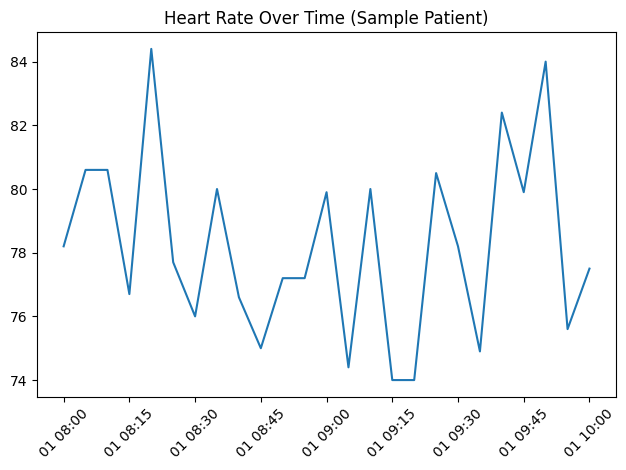

In [115]:
import matplotlib.pyplot as plt

patient_example = df[df["patient_id"] == df["patient_id"].iloc[0]]

plt.figure()
plt.plot(patient_example["timestamp"], patient_example["heart_rate"])
plt.title("Heart Rate Over Time (Sample Patient)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Create the Cycle II Target (Next Step)
Generate a forward-looking deterioration label for baseline modeling.

In [116]:
LOOKAHEAD_STEPS = 12  # 60 minutes / 5-minute bins

df = df.sort_values(["patient_id", "timestamp"]).reset_index(drop=True).copy()

df["event_now"] = (
    (df["spo2"] < 90) |
    (df["sbp"] < 90) |
    (df["heart_rate"] > 130) |
    (df["resp_rate"] > 30) |
    (df["temperature"] > 39) |
    (df["temperature"] < 35)
).astype(int)

future_flags = [
    df.groupby("patient_id")["event_now"].shift(-k)
    for k in range(1, LOOKAHEAD_STEPS + 1)
]

df["target"] = (
    pd.concat(future_flags, axis=1)
    .fillna(0)
    .max(axis=1)
    .astype(int)
)

In [117]:
display(df[["patient_id", "timestamp", "event_now", "target"]].head(20))

print(df["event_now"].value_counts(dropna=False))
print(df["target"].value_counts(dropna=False))

print("Any current events?", df["event_now"].sum())
print("Any future targets?", df["target"].sum())

patients_with_events = df.loc[df["event_now"] == 1, "patient_id"].unique()
print("Patients with events:", patients_with_events[:10])
print("Number of patients with events:", len(patients_with_events))

,patient_id,timestamp,event_now,target
0,P001,2026-04-01 08:00:00,0,0
1,P001,2026-04-01 08:05:00,0,0
2,P001,2026-04-01 08:10:00,0,0
3,P001,2026-04-01 08:15:00,0,0
4,P001,2026-04-01 08:20:00,0,0
5,P001,2026-04-01 08:25:00,0,0
6,P001,2026-04-01 08:30:00,0,0
7,P001,2026-04-01 08:35:00,0,0
8,P001,2026-04-01 08:40:00,0,0
9,P001,2026-04-01 08:45:00,0,0


event_now
0    72
1     2
Name: count, dtype: int64
target
0    61
1    13
Name: count, dtype: int64
Any current events? 2
Any future targets? 13
Patients with events: ['P003']
Number of patients with events: 1


Patient selected: P003


,timestamp,spo2,sbp,heart_rate,resp_rate,temperature,event_now,target
49,2026-04-01 08:05:00,98.60,119.70,83.00,19.70,36.810,0,0
50,2026-04-01 08:10:00,98.50,114.90,77.90,19.30,36.810,0,1
51,2026-04-01 08:15:00,98.20,123.00,75.10,16.00,37.140,0,1
52,2026-04-01 08:20:00,98.20,123.00,75.10,16.00,37.140,0,1
53,2026-04-01 08:25:00,98.30,116.95,81.80,15.85,37.115,0,1
54,2026-04-01 08:30:00,98.30,116.95,81.80,15.85,37.115,0,1
55,2026-04-01 08:35:00,98.20,121.40,83.30,18.60,37.030,0,1
56,2026-04-01 08:40:00,98.30,114.70,79.40,16.80,37.120,0,1
57,2026-04-01 08:45:00,97.30,124.20,85.90,15.90,37.020,0,1
58,2026-04-01 08:50:00,98.70,131.60,85.30,18.30,37.070,0,1


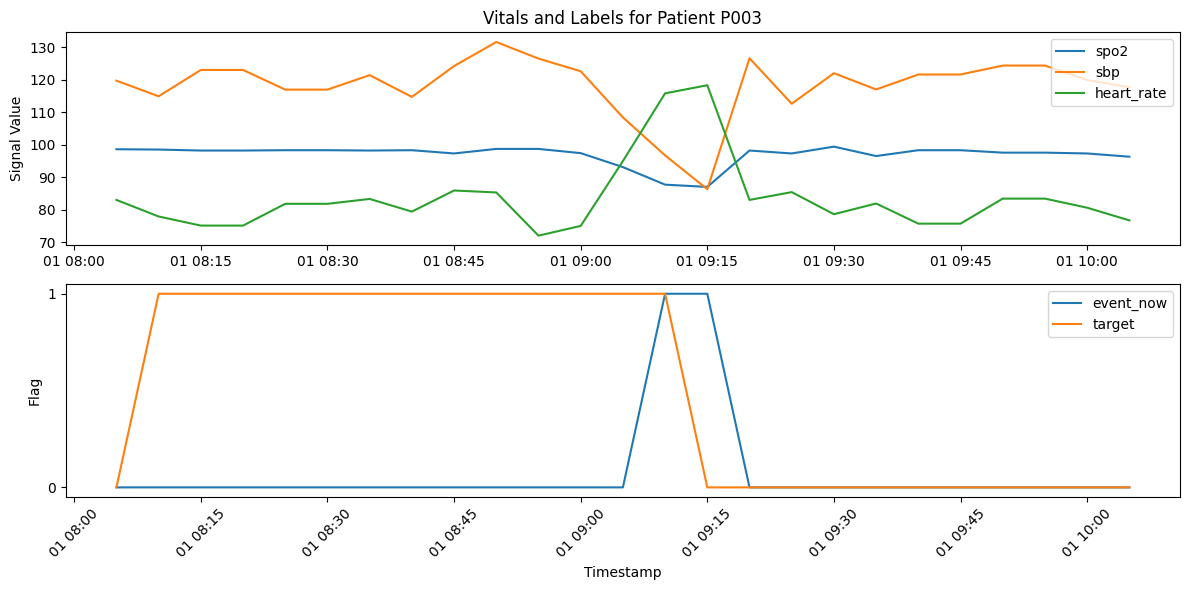

<Figure size 640x480 with 0 Axes>

In [118]:
import os
import matplotlib.pyplot as plt

os.makedirs("assets", exist_ok=True)

patient_id = patients_with_events[0]
patient_view = (
    df[df["patient_id"] == patient_id]
    .sort_values("timestamp")
    .copy()
)

print("Patient selected:", patient_id)
display(
    patient_view[
        ["timestamp", "spo2", "sbp", "heart_rate", "resp_rate", "temperature", "event_now", "target"]
    ]
)

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(patient_view["timestamp"], patient_view["spo2"], label="spo2")
ax1.plot(patient_view["timestamp"], patient_view["sbp"], label="sbp")
ax1.plot(patient_view["timestamp"], patient_view["heart_rate"], label="heart_rate")
ax1.set_title(f"Vitals and Labels for Patient {patient_id}")
ax1.set_ylabel("Signal Value")
ax1.legend()

ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(patient_view["timestamp"], patient_view["event_now"], label="event_now")
ax2.plot(patient_view["timestamp"], patient_view["target"], label="target")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Flag")
ax2.set_yticks([0, 1])
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig("assets/target_timeline_p003.png", dpi=300, bbox_inches="tight")
plt.show()

Patient selected: P003


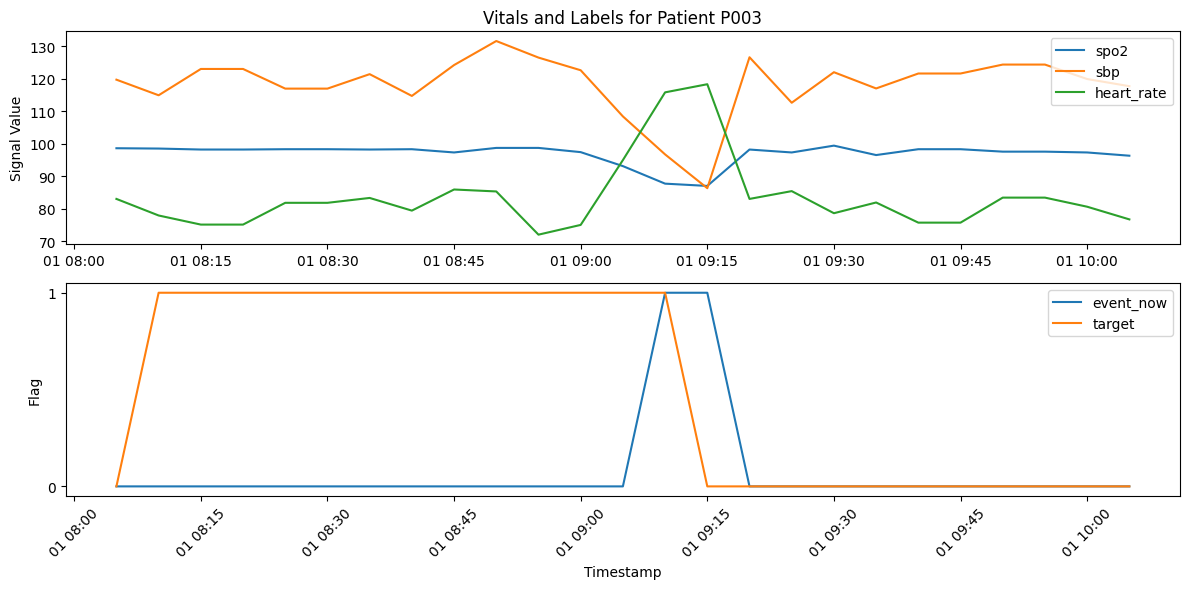

Saved to: assets/target_timeline_P003.png


In [119]:
import os
import matplotlib.pyplot as plt

repo_assets = "/kaggle/working/ProjectSixthSenseV1/assets"
os.makedirs(repo_assets, exist_ok=True)

patient_id = patients_with_events[0]
patient_view = (
    df[df["patient_id"] == patient_id]
    .sort_values("timestamp")
    .copy()
)

print("Patient selected:", patient_id)

fig = plt.figure(figsize=(12, 6), facecolor="white")

ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(patient_view["timestamp"], patient_view["spo2"], label="spo2")
ax1.plot(patient_view["timestamp"], patient_view["sbp"], label="sbp")
ax1.plot(patient_view["timestamp"], patient_view["heart_rate"], label="heart_rate")
ax1.set_title(f"Vitals and Labels for Patient {patient_id}")
ax1.set_ylabel("Signal Value")
ax1.legend()

ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(patient_view["timestamp"], patient_view["event_now"], label="event_now")
ax2.plot(patient_view["timestamp"], patient_view["target"], label="target")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Flag")
ax2.set_yticks([0, 1])
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()


plt.tight_layout()

import os
os.makedirs("assets", exist_ok=True)

plot_path = f"assets/target_timeline_{patient_id}.png"

plt.tight_layout()

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()   # show BEFORE close (optional)
plt.close()

print("Saved to:", plot_path)

## 6. Validate Target Construction
Check class balance and inspect target alignment over time.

In [120]:
from pandas.api.types import is_numeric_dtype, is_bool_dtype

EXCLUDE_COLS = {
    "patient_id",
    "timestamp",
    "event_now",   # intentionally excluded
    "target",
}

LEAKAGE_PATTERNS = [
    "target",
    "future",
    "lead",
    "next",
]

feature_cols = []
for col in df.columns:
    if col in EXCLUDE_COLS:
        continue

    col_lower = col.lower()
    if any(p in col_lower for p in LEAKAGE_PATTERNS):
        continue

    if is_numeric_dtype(df[col]) or is_bool_dtype(df[col]):
        feature_cols.append(col)

feature_cols = sorted(feature_cols)

print("Feature count:", len(feature_cols))
print(feature_cols[:20])

Feature count: 48
['dbp', 'dbp_delta', 'dbp_lag1', 'dbp_lag2', 'dbp_rolling_max_6', 'dbp_rolling_mean_6', 'dbp_rolling_min_6', 'dbp_rolling_std_6', 'heart_rate', 'heart_rate_delta', 'heart_rate_lag1', 'heart_rate_lag2', 'heart_rate_rolling_max_6', 'heart_rate_rolling_mean_6', 'heart_rate_rolling_min_6', 'heart_rate_rolling_std_6', 'resp_rate', 'resp_rate_delta', 'resp_rate_lag1', 'resp_rate_lag2']


In [121]:
print("Target distribution:")
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

Target distribution:
target
0    61
1    13
Name: count, dtype: int64
target
0    0.824324
1    0.175676
Name: proportion, dtype: float64


## 7. Train / Validation / Test Split (Patient-Level)

 Why patient-level split?
 - Because multiple rows belong to the same patient over time.
 Splitting by rows would leak patient-specific patterns across sets.

 Why PR-AUC?
 - Because deterioration events are rare, and PR-AUC is more informative
 than ROC-AUC under heavy class imbalance.

 Why class_weight='balanced'?
- To reduce bias toward the majority non-event class in the baseline model.

In [122]:
from sklearn.model_selection import train_test_split

# unique patients
patients = df["patient_id"].unique()

# split patients (not rows!)
train_p, temp_p = train_test_split(patients, test_size=0.4, random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=0.5, random_state=42)

train_df = df[df["patient_id"].isin(train_p)]
val_df   = df[df["patient_id"].isin(val_p)]
test_df  = df[df["patient_id"].isin(test_p)]

X_train, y_train = train_df[feature_cols], train_df["target"]
X_val, y_val     = val_df[feature_cols], val_df["target"]
X_test, y_test   = test_df[feature_cols], test_df["target"]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (25, 48)
Val: (25, 48)
Test: (24, 48)


## 8. Baseline Model (Logistic Regression)

In [123]:
# -----------------------------
# Logistic Regression Baseline
# -----------------------------
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
        solver="liblinear",
    )),
])

logreg_pipeline.fit(X_train, y_train)

print("Baseline logistic regression fitted.")

Baseline logistic regression fitted.


## 9. Model Evaluation

In [124]:
# -----------------------------
# Handle class imbalance
# -----------------------------
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos

# avoid division by zero
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1

print("Positive samples:", n_pos)
print("Negative samples:", n_neg)
print("scale_pos_weight:", scale_pos_weight)

Positive samples: 13
Negative samples: 12
scale_pos_weight: 0.9230769230769231


In [125]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_binary_model(model, X, y, split_name="split"):
    y_proba = model.predict_proba(X)[:, 1]

    results = {
        "split": split_name,
        "n_rows": len(y),
        "positive_rate": float(np.mean(y)),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
    }

    if y.nunique() >= 2:
        results["roc_auc"] = roc_auc_score(y, y_proba)
        results["pr_auc"] = average_precision_score(y, y_proba)
    else:
        print(f"Warning: {split_name} has only one class.")

    return results, y_proba

val_results, val_proba = evaluate_binary_model(logreg_pipeline, X_val, y_val, "val")
test_results, test_proba = evaluate_binary_model(logreg_pipeline, X_test, y_test, "test")

results_df = pd.DataFrame([val_results, test_results])
display(results_df)

,split,n_rows,positive_rate,roc_auc,pr_auc
0,val,25,0.0,NaN,NaN
1,test,24,0.0,NaN,NaN


In [126]:
print(feature_cols)

['dbp', 'dbp_delta', 'dbp_lag1', 'dbp_lag2', 'dbp_rolling_max_6', 'dbp_rolling_mean_6', 'dbp_rolling_min_6', 'dbp_rolling_std_6', 'heart_rate', 'heart_rate_delta', 'heart_rate_lag1', 'heart_rate_lag2', 'heart_rate_rolling_max_6', 'heart_rate_rolling_mean_6', 'heart_rate_rolling_min_6', 'heart_rate_rolling_std_6', 'resp_rate', 'resp_rate_delta', 'resp_rate_lag1', 'resp_rate_lag2', 'resp_rate_rolling_max_6', 'resp_rate_rolling_mean_6', 'resp_rate_rolling_min_6', 'resp_rate_rolling_std_6', 'sbp', 'sbp_delta', 'sbp_lag1', 'sbp_lag2', 'sbp_rolling_max_6', 'sbp_rolling_mean_6', 'sbp_rolling_min_6', 'sbp_rolling_std_6', 'spo2', 'spo2_delta', 'spo2_lag1', 'spo2_lag2', 'spo2_rolling_max_6', 'spo2_rolling_mean_6', 'spo2_rolling_min_6', 'spo2_rolling_std_6', 'temperature', 'temperature_delta', 'temperature_lag1', 'temperature_lag2', 'temperature_rolling_max_6', 'temperature_rolling_mean_6', 'temperature_rolling_min_6', 'temperature_rolling_std_6']


In [127]:
print("Train target counts:")
print(y_train.value_counts())

print("\nVal target counts:")
print(y_val.value_counts())

print("\nTest target counts:")
print(y_test.value_counts())

Train target counts:
target
1    13
0    12
Name: count, dtype: int64

Val target counts:
target
0    25
Name: count, dtype: int64

Test target counts:
target
0    24
Name: count, dtype: int64


## 10. Evaluation

In [128]:
model = logreg_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_[0],
    "abs_coefficient": np.abs(model.coef_[0]),
}).sort_values("abs_coefficient", ascending=False)


display(coef_df.head(15))

,feature,coefficient,abs_coefficient
5,dbp_rolling_mean_6,-0.588272,0.588272
40,temperature,0.580918,0.580918
46,temperature_rolling_min_6,0.554980,0.554980
4,dbp_rolling_max_6,-0.537604,0.537604
36,spo2_rolling_max_6,-0.519022,0.519022
2,dbp_lag1,-0.466760,0.466760
6,dbp_rolling_min_6,-0.420044,0.420044
3,dbp_lag2,-0.415707,0.415707
17,resp_rate_delta,0.353021,0.353021
47,temperature_rolling_std_6,-0.293934,0.293934


In [129]:
# Summary Cell
print(df.head())
print(df.columns)
print(df.isna().sum())

  patient_id           timestamp  heart_rate  resp_rate  spo2  temperature  \
0       P001 2026-04-01 08:00:00        78.2       17.7  98.4        36.87   
1       P001 2026-04-01 08:05:00        80.6       15.9  97.9        36.90   
2       P001 2026-04-01 08:10:00        80.6       15.9  97.9        36.90   
3       P001 2026-04-01 08:15:00        76.7       15.5  98.4        37.05   
4       P001 2026-04-01 08:20:00        84.4       15.4  97.6        36.88   

     sbp   dbp  heart_rate_lag1  heart_rate_lag2  ...  sbp_rolling_max_6  \
0  119.8  72.2              NaN              NaN  ...                NaN   
1  124.1  75.4             78.2              NaN  ...              119.8   
2  124.1  75.4             80.6             78.2  ...              124.1   
3  120.1  77.7             80.6             80.6  ...              124.1   
4  121.1  80.5             76.7             80.6  ...              124.1   

   dbp_lag1  dbp_lag2  dbp_delta  dbp_rolling_mean_6  dbp_rolling_std_6  \

## 11. XGBoost Upgrade

- XGBoost is a stronger nonlinear model for tabular temporal features
- current evaluation is limited by too few positive patients
- so this section is an upgrade demonstration, not a final benchmark

In [130]:
# XGBoost upgrade
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

In [131]:
# -----------------------------
# Prepare data for XGBoost
# -----------------------------
imputer = SimpleImputer(strategy="median") # impute features for tree model

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

X_val_imp = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("Imputed shapes:")
print("Train:", X_train_imp.shape)
print("Val:  ", X_val_imp.shape)
print("Test: ", X_test_imp.shape)

Imputed shapes:
Train: (25, 48)
Val:   (25, 48)
Test:  (24, 48)


In [132]:
# -----------------------------
# Train XGBoost classifier
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

xgb_model.fit(X_train_imp, y_train)

print("XGBoost model fitted.")

XGBoost model fitted.


In [133]:
# -----------------------------
# Evaluate XGBoost model
# -----------------------------
xgb_val_results, xgb_val_proba = evaluate_binary_model(
    xgb_model, X_val_imp, y_val, "val"
)

xgb_test_results, xgb_test_proba = evaluate_binary_model(
    xgb_model, X_test_imp, y_test, "test"
)

xgb_results_df = pd.DataFrame([xgb_val_results, xgb_test_results])

display(xgb_results_df)

,split,n_rows,positive_rate,roc_auc,pr_auc
0,val,25,0.0,NaN,NaN
1,test,24,0.0,NaN,NaN


In [134]:
# -----------------------------
# Evaluation helper
# -----------------------------
def evaluate_binary_model(model, X, y, split_name="split"):
    y_proba = model.predict_proba(X)[:, 1]

    results = {
        "split": split_name,
        "n_rows": len(y),
        "positive_rate": float(np.mean(y)),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
    }

    if y.nunique() >= 2:
        results["roc_auc"] = roc_auc_score(y, y_proba)
        results["pr_auc"] = average_precision_score(y, y_proba)
    else:
        print(f"Warning: {split_name} has only one class.")

    return results, y_proba

In [138]:
# -----------------------------
# Compare Logistic Regression vs XGBoost
# -----------------------------
logreg_results_df = results_df.copy()
ignore_index=True

logreg_results_named["model"] = "logistic_regression"

xgb_results_named = xgb_results_df.copy()
xgb_results_named["model"] = "xgboost"

comparison_df = pd.concat(
    [logreg_results_named, xgb_results_named],
    ignore_index=True
)[["model", "split", "n_rows", "positive_rate", "roc_auc", "pr_auc"]]

display(comparison_df.sort_values(["split", "model"]))

,model,split,n_rows,positive_rate,roc_auc,pr_auc
1,logistic_regression,test,24,0.0,NaN,NaN
3,xgboost,test,24,0.0,NaN,NaN
0,logistic_regression,val,25,0.0,NaN,NaN
2,xgboost,val,25,0.0,NaN,NaN


In [ ]:
'''  
*** NOT USING RIGHT NOW DUE TO HAVING ONE POSITIVE PATIENT (NEED 2+) ****

from sklearn.model_selection import train_test_split

patient_target_summary = (
    df.groupby("patient_id")["target"]
    .max()
    .reset_index()
    .rename(columns={"target": "has_positive"})
)

train_patients, temp_patients = train_test_split(
    patient_target_summary,
    test_size=0.40,
    random_state=42,
    stratify=patient_target_summary["has_positive"],
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42,
    stratify=temp_patients["has_positive"],
)

train_ids = train_patients["patient_id"].tolist()
val_ids = val_patients["patient_id"].tolist()
test_ids = test_patients["patient_id"].tolist()

train_df = df[df["patient_id"].isin(train_ids)].copy()
val_df = df[df["patient_id"].isin(val_ids)].copy()
test_df = df[df["patient_id"].isin(test_ids)].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df["target"].astype(int).copy()

X_val = val_df[feature_cols].copy()
y_val = val_df["target"].astype(int).copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["target"].astype(int).copy()

print("Train target counts:")
print(y_train.value_counts())

print("\nVal target counts:")
print(y_val.value_counts())

print("\nTest target counts:")
print(y_test.value_counts())

**** NOT USING DUE TO HAVING ONLY ONE POSITIVE PATIENT (NEED 2+) ******
''' 

# 12. Alerting Framework & Clinical Sensitivity

### Threshold Selection Note

Initial threshold exploration suggests that very low thresholds (e.g., 0.1–0.2) would generate excessive alerts, increasing the risk of alert fatigue. Higher thresholds (e.g., 0.3 and above) are much more conservative, but current data limitations prevent robust assessment of missed events.

For this stage of the project, a provisional threshold near **0.26** is selected as a practical compromise between alert burden and sensitivity. This choice is preliminary and will be re-evaluated once additional positive patient cases are available.

In [141]:
# -----------------------------
# Threshold tuning (clinical focus)
# -----------------------------
from sklearn.metrics import precision_score, recall_score

thresholds = [0.26, 0.27, 0.28, 0.285, 0.287, 0.29, 0.30]

rows = []

for t in thresholds:
    y_pred = (xgb_test_proba >= t).astype(int)

    if y_test.nunique() >= 2:
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
    else:
        precision = None
        recall = None

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "alerts_triggered": int(y_pred.sum())
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

,threshold,precision,recall,alerts_triggered
0,0.260,None,None,2
1,0.270,None,None,2
2,0.280,None,None,1
3,0.285,None,None,1
4,0.287,None,None,1
5,0.290,None,None,1
6,0.300,None,None,1


### Provisional Threshold Selection

Threshold exploration identified a practical operating region between 0.26 and 0.28. A provisional threshold of **0.27** was selected because it substantially reduces alert burden while remaining less restrictive than the more conservative 0.28+ range.

At the current stage, this threshold should be interpreted as a design choice for operational testing rather than a finalized clinical cutoff, given the limited number of positive patients in the dataset.

In [142]:
threshold = 0.27

alert_df = test_df.copy()
alert_df["pred_proba"] = xgb_test_proba
alert_df["alert_flag"] = (alert_df["pred_proba"] >= threshold).astype(int)

flagged_alerts = alert_df.loc[
    alert_df["alert_flag"] == 1,
    ["patient_id", "timestamp", "target", "pred_proba"]
]

display(flagged_alerts)
print("Alerts triggered:", flagged_alerts.shape[0])

,patient_id,timestamp,target,pred_proba
27,P002,2026-04-01 08:15:00,0,0.934587
46,P002,2026-04-01 09:50:00,0,0.273016


Alerts triggered: 2


In [144]:
# Checking to see if the triggered alerts are noisy, clinically plausable or operationally acceptable.
p002_view = df[df["patient_id"] == "P002"].sort_values("timestamp").copy()

display(p002_view[[
    "timestamp", "heart_rate", "resp_rate", "spo2", "temperature", "sbp", "dbp",
    "event_now", "target"
]])

,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,event_now,target
25,2026-04-01 08:05:00,81.50,18.00,97.5,37.140,120.2,76.30,0,0
26,2026-04-01 08:10:00,79.80,18.70,98.8,37.140,120.5,80.40,0,0
27,2026-04-01 08:15:00,89.10,19.20,97.0,37.250,121.7,83.70,0,0
28,2026-04-01 08:20:00,87.30,17.90,96.0,37.250,125.9,78.10,0,0
29,2026-04-01 08:25:00,87.30,21.60,95.8,37.150,120.6,77.00,0,0
30,2026-04-01 08:30:00,90.00,20.10,96.5,37.360,117.4,79.70,0,0
31,2026-04-01 08:35:00,90.00,20.10,96.5,37.360,117.4,79.70,0,0
32,2026-04-01 08:40:00,90.65,20.10,95.3,37.225,113.1,78.10,0,0
33,2026-04-01 08:45:00,96.40,23.20,95.1,37.280,113.1,77.10,0,0
34,2026-04-01 08:50:00,96.15,21.45,94.2,37.370,118.2,80.35,0,0


### Observations

At the selected threshold (0.27), the model generated alerts for patient P002 at two timepoints.

Interestingly, the earlier alert (08:15) received a significantly higher predicted probability (>0.93), despite raw vital signs appearing within normal ranges. This suggests that the model is leveraging temporal features (e.g., rate of change, rolling variability) rather than relying solely on absolute thresholds.

This behavior is desirable for early warning systems, but must be interpreted cautiously given the limited number of positive samples available.

In [145]:
cols_to_check = [
    "patient_id", "timestamp",
    "heart_rate", "resp_rate", "spo2", "temperature", "sbp", "dbp",
    "heart_rate_lag1", "heart_rate_lag2", "heart_rate_delta",
    "heart_rate_rolling_mean_6", "heart_rate_rolling_std_6", "heart_rate_rolling_max_6",
    "spo2_lag1", "spo2_lag2", "spo2_delta",
    "spo2_rolling_mean_6", "spo2_rolling_std_6", "spo2_rolling_min_6",
    "dbp_lag1", "dbp_lag2", "dbp_delta",
    "dbp_rolling_mean_6", "dbp_rolling_std_6", "dbp_rolling_min_6",
    "event_now", "target"
]

display(
    df.loc[df.index.isin([27, 46]), [c for c in cols_to_check if c in df.columns]]
)

,patient_id,timestamp,heart_rate,resp_rate,spo2,temperature,sbp,dbp,heart_rate_lag1,heart_rate_lag2,...,spo2_rolling_std_6,spo2_rolling_min_6,dbp_lag1,dbp_lag2,dbp_delta,dbp_rolling_mean_6,dbp_rolling_std_6,dbp_rolling_min_6,event_now,target
27,P002,2026-04-01 08:15:00,89.1,19.2,97.0,37.25,121.7,83.7,79.8,81.5,...,0.919239,97.5,80.4,76.3,3.3,78.350000,2.899138,76.3,0,0
46,P002,2026-04-01 09:50:00,114.9,27.7,90.9,37.70,94.0,71.5,113.1,115.2,...,0.936839,90.6,63.3,71.6,8.2,70.116667,4.151827,63.3,0,0


### Alert Behavior Inspection

Inspection of flagged rows suggests that BIRE is reacting to temporal instability rather than absolute threshold violations alone.

At 08:15, raw vitals were not overtly critical, but recent changes in heart rate, diastolic blood pressure, and oxygenation relative to the preceding window produced a high risk score. This indicates that the model is sensitive to trajectory shifts and short-term instability.

At 09:50, the patient appeared more visibly unstable from the raw vitals alone, with higher heart rate and respiratory rate, lower oxygen saturation, and lower systolic pressure. The lower predicted probability relative to 08:15 likely reflects the current limitation of the training data, where extremely few positive examples may cause the model to overfit a narrow deterioration pattern.

Overall, these results support the idea that BIRE is learning temporal risk structure, but they also highlight the need for more positive patient examples before alert ranking can be treated as clinically reliable.

## Step 13: Model Stability & Reliability Testing

## 14. Summary Statement for Stakeholders

*(Translating technical results into clinical impact)*

> *The BIRE system is designed to detect early physiological deviations by analyzing temporal trends in patient vital signs, rather than relying solely on threshold-based rules.Initial results demonstrate that the model is capable of identifying patterns of instability that may precede overt clinical deterioration. In particular, the system responds to changes in trajectory and variability, not just absolute measurements.While these findings are promising, the current dataset contains a limited number of positive deterioration events. As a result, further validation on larger and more diverse patient cohorts is required before clinical deployment.Future work will focus on improving model stability, refining alert thresholds, and ensuring reliable performance across varying patient populations.*

In [146]:
git add .

git commit -m "Add threshold tuning and alerting framework (BIRE v1)"
git push

SyntaxError: invalid syntax (1828340619.py, line 1)